## Authorship

- **Course / code author:** Xinze Li  
- **Tutorial article:** Xinze Li, Fanfan Lin, Juan J. Rodríguez-Andina, Sergio Vazquez, Homer Alan Mantooth, Leopoldo García Franquelo, "Fundamentals of Artificial Intelligences for Power Electronics," *IEEE Transactions on Industrial Electronics*, 2026.

*These learning resources are still under active refinement; notebooks, data, and documentation may change.*

---



### Tutorials for Ensemble Algorithms
 * Popular ensemble learning algorithms for regression and classification problems
   1. Random forest
   2. xgboost
* Artificial examples to test when xgboost and random forest are likely to fail
   1. Highly correlated input features
   2. Class imbalance (classification)
   3. Noisy labels (output domain)
* Benchmark datasets
   1. Regression: from sklearn.datasets import fetch_california_housing
   2. Classification: from sklearn.datasets import load_breast_cancer
* Explain your EL model
   1. Graphviz
   2. Shapley
* Bayesian optimization for hyperparameter and display algorithm performances using Pareto front

In [1]:
%load_ext autoreload
%autoreload 2

#### 1 Artificial examples to test when xgboost and random forest are likely to fail

##### 1.1 Highly correlated input features

In [2]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb
import matplotlib.pyplot as plt

# Seed for reproducibility
np.random.seed(42)

# 1. Generate true signal
n_samples = 50
X_signal = np.random.randn(n_samples, 1)
y = (X_signal[:, 0] > 0).astype(int)  # Binary label depends on the sign of X_signal

# 2. Add 20 highly correlated redundant features
X_noise = X_signal + np.random.randn(n_samples, 20)*0.5
X = np.hstack([X_signal, X_noise])  # 1 true feature + 20 noisy correlated ones

# Repeat the experiment 10 times and store accuracies
n_repeats = 10
rf_accuracies = []
xgb_accuracies = []
dt_accuracies = []


for i in range(n_repeats):
    # Split data with a different random state each time
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=42 + i
    )

    # Train Random Forest
    rf = RandomForestClassifier(
        n_estimators=10,
        max_depth=3,
        min_samples_split=5,      # Increased for stronger regularization
        min_samples_leaf=1,        # Increased for stronger regularization
        random_state=42 + i
    )
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    rf_accuracies.append(accuracy_score(y_test, y_pred_rf))

    # Train XGBoost
    xgb_clf = xgb.XGBClassifier(
        n_estimators=10,
        max_depth=3,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42 + i
    )
    xgb_clf.fit(X_train, y_train)
    y_pred_xgb = xgb_clf.predict(X_test)
    xgb_accuracies.append(accuracy_score(y_test, y_pred_xgb))

    # Train Decision Tree
    dt_clf = DecisionTreeClassifier(
        max_depth=3,
        min_samples_split=5,
        min_samples_leaf=1,
        random_state=42 + i
    )
    dt_clf.fit(X_train, y_train)
    y_pred_dt = dt_clf.predict(X_test)
    dt_accuracies.append(accuracy_score(y_test, y_pred_dt))



d:\Anaconda\lib\site-packages\xgboost\compat.py:36: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index


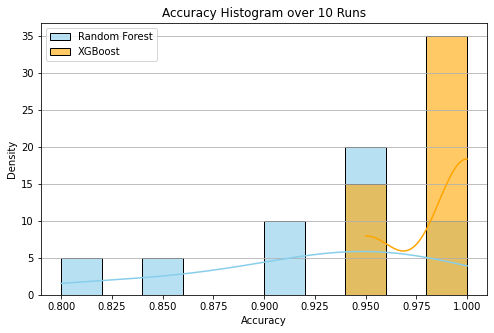

Random Forest Accuracies: [0.9, 0.9, 0.95, 0.95, 1.0, 0.8, 0.95, 0.85, 0.95, 1.0]
XGBoost Accuracies: [0.95, 1.0, 1.0, 1.0, 1.0, 0.95, 1.0, 0.95, 1.0, 1.0]
T-test statistic: -2.7941, p-value: 0.0120
Mean Random Forest Accuracy: 0.9250
Mean XGBoost Accuracy: 0.9850
The difference in accuracies is statistically significant (p < 0.05).
XGBoost performs better based on mean accuracy.


In [3]:
import seaborn as sns
from scipy.stats import ttest_ind

# Plot the histogram of both algorithms' accuracies
plt.figure(figsize=(8, 5))
bins = np.linspace(min(min(rf_accuracies), min(xgb_accuracies)), max(max(rf_accuracies), max(xgb_accuracies)), 11)
sns.histplot(rf_accuracies, bins=bins, color='skyblue', label='Random Forest', kde=True, stat='density', alpha=0.6)
sns.histplot(xgb_accuracies, bins=bins, color='orange', label='XGBoost', kde=True, stat='density', alpha=0.6)
plt.xlabel('Accuracy')
plt.ylabel('Density')
plt.title('Accuracy Histogram over 10 Runs')
plt.legend()
plt.grid(True, axis='y')
plt.show()

# Perform t-test
t_stat, p_value = ttest_ind(rf_accuracies, xgb_accuracies)
print("Random Forest Accuracies:", rf_accuracies)
print("XGBoost Accuracies:", xgb_accuracies)
print(f"T-test statistic: {t_stat:.4f}, p-value: {p_value:.4f}")

mean_rf = np.mean(rf_accuracies)
mean_xgb = np.mean(xgb_accuracies)

if mean_rf > mean_xgb:
    better = "Random Forest"
elif mean_xgb > mean_rf:
    better = "XGBoost"
else:
    better = "Both algorithms have the same mean accuracy"

print(f"Mean Random Forest Accuracy: {mean_rf:.4f}")
print(f"Mean XGBoost Accuracy: {mean_xgb:.4f}")

if p_value < 0.05:
    print("The difference in accuracies is statistically significant (p < 0.05).")
    print(f"{better} performs better based on mean accuracy.")
else:
    print("The difference in accuracies is not statistically significant (p >= 0.05).")
    print(f"{better} performs better based on mean accuracy, but the difference is not statistically significant.")

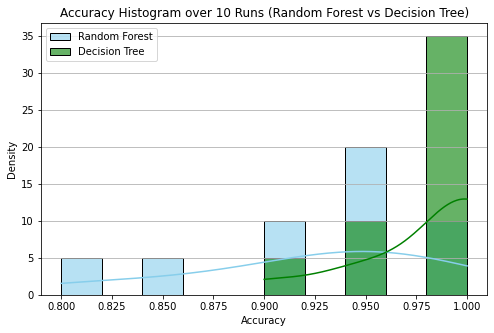

Random Forest Accuracies: [0.9, 0.9, 0.95, 0.95, 1.0, 0.8, 0.95, 0.85, 0.95, 1.0]
Decision Tree Accuracies: [0.95, 1.0, 1.0, 1.0, 1.0, 0.95, 1.0, 0.9, 1.0, 1.0]
T-test statistic: -2.4004, p-value: 0.0274
Mean Random Forest Accuracy: 0.9250
Mean Decision Tree Accuracy: 0.9800
The difference in accuracies is statistically significant (p < 0.05).
Decision Tree performs better based on mean accuracy.


In [4]:
# Compare Random Forest and Decision Tree accuracies

# Plot the histogram of both algorithms' accuracies
plt.figure(figsize=(8, 5))
bins = np.linspace(min(min(rf_accuracies), min(dt_accuracies)), max(max(rf_accuracies), max(dt_accuracies)), 11)
sns.histplot(rf_accuracies, bins=bins, color='skyblue', label='Random Forest', kde=True, stat='density', alpha=0.6)
sns.histplot(dt_accuracies, bins=bins, color='green', label='Decision Tree', kde=True, stat='density', alpha=0.6)
plt.xlabel('Accuracy')
plt.ylabel('Density')
plt.title('Accuracy Histogram over 10 Runs (Random Forest vs Decision Tree)')
plt.legend()
plt.grid(True, axis='y')
plt.show()

# Perform t-test
t_stat_dt, p_value_dt = ttest_ind(rf_accuracies, dt_accuracies)
print("Random Forest Accuracies:", rf_accuracies)
print("Decision Tree Accuracies:", dt_accuracies)
print(f"T-test statistic: {t_stat_dt:.4f}, p-value: {p_value_dt:.4f}")

mean_rf = np.mean(rf_accuracies)
mean_dt = np.mean(dt_accuracies)

if mean_rf > mean_dt:
    better_dt = "Random Forest"
elif mean_dt > mean_rf:
    better_dt = "Decision Tree"
else:
    better_dt = "Both algorithms have the same mean accuracy"

print(f"Mean Random Forest Accuracy: {mean_rf:.4f}")
print(f"Mean Decision Tree Accuracy: {mean_dt:.4f}")

if p_value_dt < 0.05:
    print("The difference in accuracies is statistically significant (p < 0.05).")
    print(f"{better_dt} performs better based on mean accuracy.")
else:
    print("The difference in accuracies is not statistically significant (p >= 0.05).")
    print(f"{better_dt} performs better based on mean accuracy, but the difference is not statistically significant.")


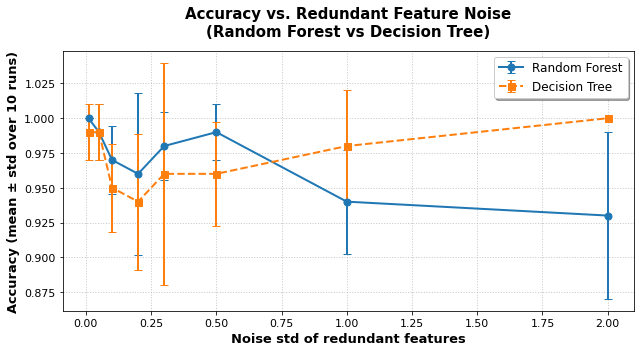

In [5]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Seed for reproducibility
np.random.seed(42)

# Sweep std values
std_list = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0, 2.0]
n_samples = 50
n_repeats = 5

rf_means = []
rf_stds = []
dt_means = []
dt_stds = []

for std in std_list:
    rf_accuracies = []
    dt_accuracies = []
    # Generate true signal
    X_signal = np.random.randn(n_samples, 1)
    y = (X_signal[:, 0] > 0).astype(int)  # Binary label depends on the sign of X_signal

    # Add 20 highly correlated redundant features
    X_noise = X_signal + np.random.randn(n_samples, 20)*std
    X = np.hstack([X_signal, X_noise])  # 1 true feature + 20 noisy correlated ones

    for i in range(n_repeats):
        # Split data with a different random state each time
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.4, random_state=42 + i
        )

        # Train Random Forest
        rf = RandomForestClassifier(
            n_estimators=10,
            max_depth=3,
            min_samples_split=5,
            min_samples_leaf=1,
            random_state=42 + i
        )
        rf.fit(X_train, y_train)
        y_pred_rf = rf.predict(X_test)
        rf_accuracies.append(accuracy_score(y_test, y_pred_rf))

        # Train Decision Tree
        dt_clf = DecisionTreeClassifier(
            max_depth=3,
            min_samples_split=5,
            min_samples_leaf=1,
            random_state=42 + i
        )
        dt_clf.fit(X_train, y_train)
        y_pred_dt = dt_clf.predict(X_test)
        dt_accuracies.append(accuracy_score(y_test, y_pred_dt))

    rf_means.append(np.mean(rf_accuracies))
    rf_stds.append(np.std(rf_accuracies))
    dt_means.append(np.mean(dt_accuracies))
    dt_stds.append(np.std(dt_accuracies))

# Plot the accuracy vs std for both models with enhanced styling
plt.figure(figsize=(9, 5))
plt.errorbar(
    std_list, rf_means, yerr=rf_stds, 
    label='Random Forest', marker='o', capsize=4, 
    color='#1f77b4', linewidth=2, markersize=7, linestyle='-'
)
plt.errorbar(
    std_list, dt_means, yerr=dt_stds, 
    label='Decision Tree', marker='s', capsize=4, 
    color='#ff7f0e', linewidth=2, markersize=7, linestyle='--'
)
plt.xlabel('Noise std of redundant features', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy (mean ± std over 10 runs)', fontsize=13, fontweight='bold')
plt.title('Accuracy vs. Redundant Feature Noise\n(Random Forest vs Decision Tree)', fontsize=15, fontweight='bold', pad=15)
plt.legend(fontsize=12, frameon=True, shadow=True, loc='best')
plt.grid(True, linestyle=':', linewidth=1, alpha=0.7)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()


Original number of features: 21
Reduced number of features after PCA: 16


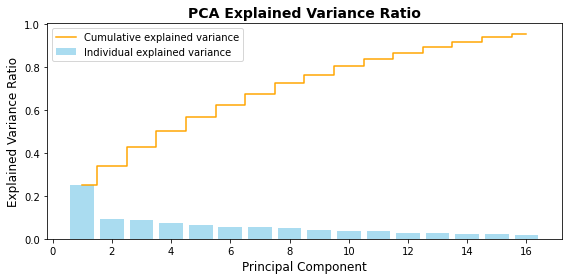

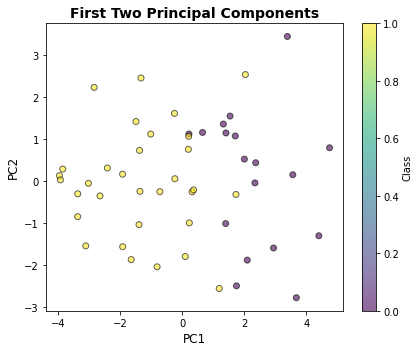

Random Forest (PCA) mean accuracy over 10 runs: 0.820 ± 0.098
Decision Tree (original) mean accuracy over 10 runs: 1.000 ± 0.000
Random Forest classification report (PCA data, last run):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         6

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

Decision Tree classification report (original features, last run):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         6

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



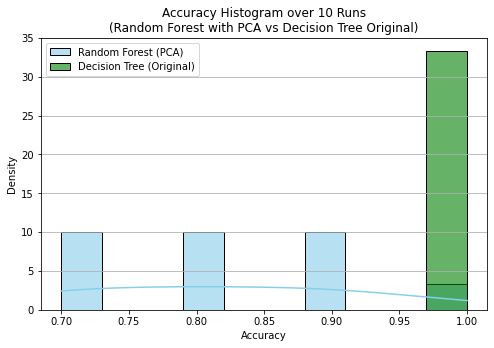

In [6]:
### Potential solutions to highly correlated input features: PCA + Model Training
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Conduct PCA to reduce dimensionality
pca = PCA(n_components=0.95)  # retain 90% of variance
X_pca = pca.fit_transform(X_scaled)

print(f"Original number of features: {X.shape[1]}")
print(f"Reduced number of features after PCA: {X_pca.shape[1]}")

# Plot explained variance ratio for each principal component
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, alpha=0.7, color='skyblue', label='Individual explained variance')
plt.step(range(1, len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_), where='mid', color='orange', label='Cumulative explained variance')
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.title('PCA Explained Variance Ratio', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# If the reduced data is at least 2D, plot the first two principal components
if X_pca.shape[1] >= 2:
    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.6, edgecolor='k')
    plt.xlabel('PC1', fontsize=12)
    plt.ylabel('PC2', fontsize=12)
    plt.title('First Two Principal Components', fontsize=14, fontweight='bold')
    plt.colorbar(scatter, label='Class')
    plt.tight_layout()
    plt.show()

# Run multiple times to get accuracy distributions for both approaches
n_runs = 10
rf_pca_accuracies = []
dt_orig_accuracies = []

for i in range(n_runs):
    # Train/test split on PCA-transformed data for Random Forest
    X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42 + i)
    rf_pca = RandomForestClassifier(
        n_estimators=10,
        max_depth=3,
        min_samples_split=5,
        min_samples_leaf=1,
        random_state=42 + i
    )
    rf_pca.fit(X_train_pca, y_train_pca)
    y_pred_rf_pca = rf_pca.predict(X_test_pca)
    rf_pca_accuracies.append(accuracy_score(y_test_pca, y_pred_rf_pca))

    # For Decision Tree, develop it on the original features (not PCA)
    X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X, y, test_size=0.2, random_state=42 + i)
    dt_orig = DecisionTreeClassifier(
        max_depth=3,
        min_samples_split=5,
        min_samples_leaf=1,
        random_state=42 + i
    )
    dt_orig.fit(X_train_orig, y_train_orig)
    y_pred_dt_orig = dt_orig.predict(X_test_orig)
    dt_orig_accuracies.append(accuracy_score(y_test_orig, y_pred_dt_orig))

# Print mean and std for both
print(f"Random Forest (PCA) mean accuracy over {n_runs} runs: {np.mean(rf_pca_accuracies):.3f} ± {np.std(rf_pca_accuracies):.3f}")
print(f"Decision Tree (original) mean accuracy over {n_runs} runs: {np.mean(dt_orig_accuracies):.3f} ± {np.std(dt_orig_accuracies):.3f}")

# Show classification report for the last run
print("Random Forest classification report (PCA data, last run):")
print(classification_report(y_test_pca, y_pred_rf_pca))
print("Decision Tree classification report (original features, last run):")
print(classification_report(y_test_orig, y_pred_dt_orig))

# Plot histogram of accuracies for both methods
plt.figure(figsize=(8, 5))
bins = np.linspace(
    min(min(rf_pca_accuracies), min(dt_orig_accuracies)),
    max(max(rf_pca_accuracies), max(dt_orig_accuracies)),
    11
)
sns.histplot(rf_pca_accuracies, bins=bins, color='skyblue', label='Random Forest (PCA)', kde=True, stat='density', alpha=0.6)
sns.histplot(dt_orig_accuracies, bins=bins, color='green', label='Decision Tree (Original)', kde=True, stat='density', alpha=0.6)
plt.xlabel('Accuracy')
plt.ylabel('Density')
plt.title('Accuracy Histogram over 10 Runs\n(Random Forest with PCA vs Decision Tree Original)')
plt.legend()
plt.grid(True, axis='y')
plt.show()


##### 1.2 Class imbalance

In [7]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import xgboost as xgb

# 1. Create an imbalanced dataset
X, y = make_classification(
    n_samples=3000,
    n_features=10,
    n_informative=3,
    n_redundant=2,
    n_clusters_per_class=1,
    weights=[0.9, 0.1],  # 90% class 0, 10% class 1
    flip_y=0,
    random_state=42
)


# Run Random Forest and XGBoost multiple times and record performances

n_repeats = 10
rf_reports = []
xgb_reports = []
rf_conf_matrices = []
xgb_conf_matrices = []

for i in range(n_repeats):
    # Split data with a different random state each time
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.1, random_state=42 + i
    )

    # Train Random Forest
    rf_clf = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42 + i
    )
    rf_clf.fit(X_train, y_train)
    y_pred_rf = rf_clf.predict(X_test)
    rf_conf_matrices.append(confusion_matrix(y_test, y_pred_rf))
    rf_reports.append(classification_report(y_test, y_pred_rf, output_dict=True))

    # Train XGBoost
    xgb_clf = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=1,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42 + i
    )
    xgb_clf.fit(X_train, y_train)
    y_pred_xgb = xgb_clf.predict(X_test)
    xgb_conf_matrices.append(confusion_matrix(y_test, y_pred_xgb))
    xgb_reports.append(classification_report(y_test, y_pred_xgb, output_dict=True))


Random Forest Results (averaged over 10 runs):
Average precision for class 0: 0.959
Average precision for class 1: 0.962
Average recall for class 0: 0.997
Average recall for class 1: 0.647
Average f1-score for class 0: 0.978
Average f1-score for class 1: 0.772
Average accuracy: 0.960

XGBoost Results (averaged over 10 runs):
Average precision for class 0: 0.976
Average precision for class 1: 0.858
Average recall for class 0: 0.984
Average recall for class 1: 0.796
Average f1-score for class 0: 0.980
Average f1-score for class 1: 0.824
Average accuracy: 0.964


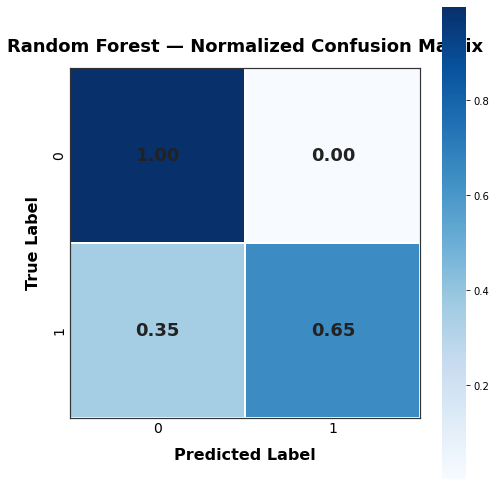

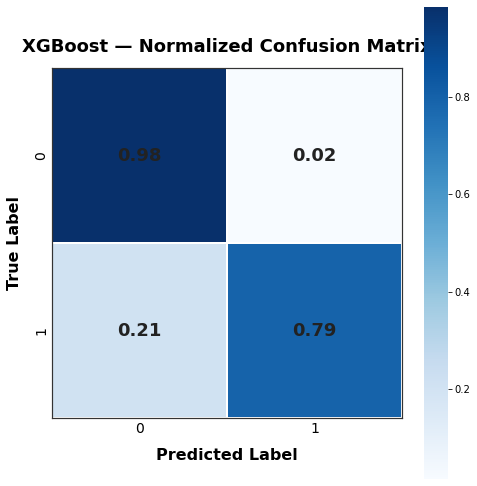

In [8]:
# Print average results
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def average_metrics(reports, classes=['0', '1']):
    # reports: list of dicts (output_dict=True from classification_report)
    metrics = {}
    for cls in classes:
        metrics[cls] = {}
        for metric in ['precision', 'recall', 'f1-score']:
            values = [report[cls][metric] for report in reports if cls in report]
            metrics[cls][metric] = np.mean(values)
    # accuracy is at the top level
    metrics['accuracy'] = np.mean([report['accuracy'] for report in reports])
    return metrics

print("Random Forest Results (averaged over {} runs):".format(n_repeats))
avg_rf_report = average_metrics(rf_reports)
print("Average precision for class 0: {:.3f}".format(avg_rf_report['0']['precision']))
print("Average precision for class 1: {:.3f}".format(avg_rf_report['1']['precision']))
print("Average recall for class 0: {:.3f}".format(avg_rf_report['0']['recall']))
print("Average recall for class 1: {:.3f}".format(avg_rf_report['1']['recall']))
print("Average f1-score for class 0: {:.3f}".format(avg_rf_report['0']['f1-score']))
print("Average f1-score for class 1: {:.3f}".format(avg_rf_report['1']['f1-score']))
print("Average accuracy: {:.3f}".format(avg_rf_report['accuracy']))

print("\nXGBoost Results (averaged over {} runs):".format(n_repeats))
avg_xgb_report = average_metrics(xgb_reports)
print("Average precision for class 0: {:.3f}".format(avg_xgb_report['0']['precision']))
print("Average precision for class 1: {:.3f}".format(avg_xgb_report['1']['precision']))
print("Average recall for class 0: {:.3f}".format(avg_xgb_report['0']['recall']))
print("Average recall for class 1: {:.3f}".format(avg_xgb_report['1']['recall']))
print("Average f1-score for class 0: {:.3f}".format(avg_xgb_report['0']['f1-score']))
print("Average f1-score for class 1: {:.3f}".format(avg_xgb_report['1']['f1-score']))
print("Average accuracy: {:.3f}".format(avg_xgb_report['accuracy']))

# Plot average accuracy matrices with a clean, professional style
def plot_avg_accuracy_matrix(conf_matrices, title, class_names=['0', '1']):
    avg_conf = np.mean(conf_matrices, axis=0)
    # Normalize by row sums to get per-class accuracy
    row_sums = avg_conf.sum(axis=1, keepdims=True)
    accuracy_matrix = avg_conf / row_sums

    plt.figure(figsize=(7, 7))
    ax = sns.heatmap(
        accuracy_matrix,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        cbar=True,
        square=True,
        linewidths=1.5,
        linecolor='white',
        xticklabels=class_names,
        yticklabels=class_names,
        annot_kws={"size": 18, "weight": "semibold", "color": "#222222"}
    )
    ax.set_xlabel('Predicted Label', fontsize=16, fontweight='semibold', labelpad=12)
    ax.set_ylabel('True Label', fontsize=16, fontweight='semibold', labelpad=12)
    ax.set_title(f"{title} — Normalized Confusion Matrix", fontsize=18, fontweight='semibold', pad=16)
    ax.tick_params(axis='both', which='major', labelsize=14, length=0)
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_color('#333333')
    plt.tight_layout()
    plt.show()

plot_avg_accuracy_matrix(rf_conf_matrices, "Random Forest")
plot_avg_accuracy_matrix(xgb_conf_matrices, "XGBoost")

##### 1.3 Noisy labels (output domain)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge

# 1. Generate data: sinusoidal signal + extreme noise
np.random.seed(42)
n_samples = 300

X = np.linspace(0, 10, n_samples).reshape(-1, 1)
y_true = np.sin(X).ravel()
noise = np.random.normal(0, 3.0, size=n_samples)  # Increase noise to make XGBoost fail
y = y_true + noise

# Repeat the experiment multiple times and apply styling to the figure

n_repeats = 10
xgb_maes = []
ridge_maes = []
xgb_preds = []
ridge_preds = []

for seed in range(n_repeats):
    # 2. Split into train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed
    )

    # 3. Fit XGBoost with regularization to mitigate overfitting
    xgb = XGBRegressor(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.5,
        random_state=seed
    )
    xgb.fit(X_train, y_train)

    # 4. Fit Ridge Regression (linear & robust)
    ridge = Ridge(alpha=10)
    ridge.fit(X_train, y_train)

    # 5. Predictions and evaluation
    y_pred_xgb = xgb.predict(X_test)
    y_pred_ridge = ridge.predict(X_test)

    xgb_maes.append(mean_absolute_error(y_test, y_pred_xgb))
    ridge_maes.append(mean_absolute_error(y_test, y_pred_ridge))
    xgb_preds.append((X_test.copy(), y_pred_xgb.copy()))
    ridge_preds.append((X_test.copy(), y_pred_ridge.copy()))

print(f"XGBoost MAE: {np.mean(xgb_maes):.3f} ± {np.std(xgb_maes):.3f}")
print(f"Ridge Regression MAE: {np.mean(ridge_maes):.3f} ± {np.std(ridge_maes):.3f}")


XGBoost MAE: 3.450 ± 0.238
Ridge Regression MAE: 2.380 ± 0.126


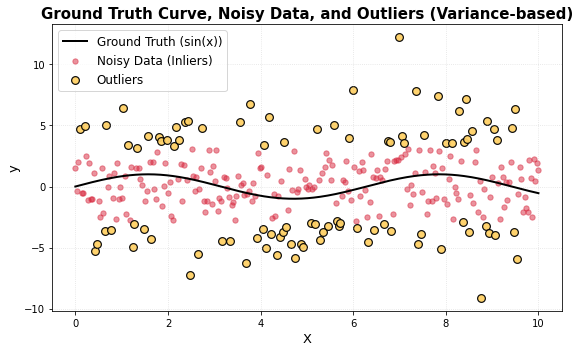

XGBoost MAE on cleaned data: 1.824 ± 0.102
Ridge Regression MAE on cleaned data: 1.302 ± 0.079


In [10]:
# Outlier detection based on variance (z-score method)
from scipy.stats import zscore

# Compute z-scores of the noisy data
y_zscores = zscore(y)
outlier_threshold = 1  # You can adjust this threshold
outlier_mask = np.abs(y_zscores) > outlier_threshold

# Cleaned dataset: remove outliers
X_clean = X[~outlier_mask].reshape(-1, 1)
y_clean = y[~outlier_mask]

# Plotting the cleaned data and outliers for reference
plt.figure(figsize=(8, 5))
plt.plot(X, y_true, color='black', linewidth=2, label='Ground Truth (sin(x))')
plt.scatter(X_clean, y_clean, color='#D7263D', alpha=0.5, s=28, label='Noisy Data (Inliers)')
plt.scatter(X[outlier_mask], y[outlier_mask], color='#FFD166', edgecolor='black', alpha=0.95, s=60, label='Outliers', marker='o', linewidth=1.2)
plt.xlabel("X", fontsize=13)
plt.ylabel("y", fontsize=13)
plt.title("Ground Truth Curve, Noisy Data, and Outliers (Variance-based)", fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

# Train both algorithms on the cleaned dataset with the same settings as before
n_repeats_clean = 10
xgb_maes_clean = []
ridge_maes_clean = []

for seed in range(n_repeats_clean):
    # Split cleaned data into train/test
    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
        X_clean, y_clean, test_size=0.3, random_state=seed
    )

    # Fit XGBoost
    xgb_c = XGBRegressor(n_estimators=500, max_depth=8, learning_rate=0.05, random_state=seed)
    xgb_c.fit(X_train_c, y_train_c)

    # Fit Ridge Regression
    ridge_c = Ridge(alpha=10)
    ridge_c.fit(X_train_c, y_train_c)

    # Predictions and evaluation
    y_pred_xgb_c = xgb_c.predict(X_test_c)
    y_pred_ridge_c = ridge_c.predict(X_test_c)

    xgb_maes_clean.append(mean_absolute_error(y_test_c, y_pred_xgb_c))
    ridge_maes_clean.append(mean_absolute_error(y_test_c, y_pred_ridge_c))

print(f"XGBoost MAE on cleaned data: {np.mean(xgb_maes_clean):.3f} ± {np.std(xgb_maes_clean):.3f}")
print(f"Ridge Regression MAE on cleaned data: {np.mean(ridge_maes_clean):.3f} ± {np.std(ridge_maes_clean):.3f}")


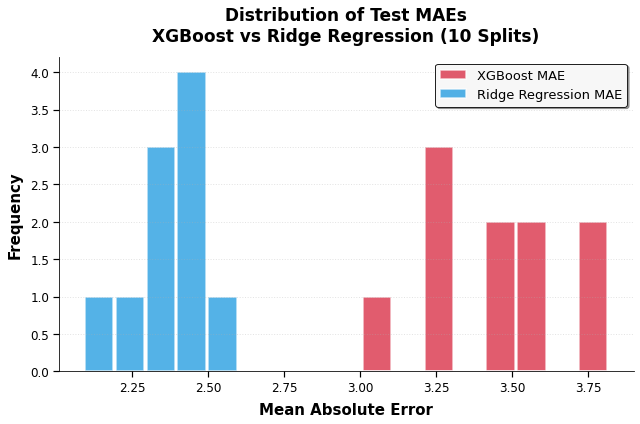

P-value for paired t-test: 2.38e-08
Ridge Regression has the lower average MAE.


In [11]:
# 6. Visualization: Plot histogram of MAEs for both algorithms (styled, more bins)

plt.figure(figsize=(9, 6))
bins = np.linspace(
    min(min(xgb_maes), min(ridge_maes)),
    max(max(xgb_maes), max(ridge_maes)),
    18  # Increased number of bins for finer granularity
)

plt.hist(
    xgb_maes, bins=bins, alpha=0.75, color='#D7263D', label='XGBoost MAE',
    edgecolor='white', linewidth=1.5, rwidth=0.92
)
plt.hist(
    ridge_maes, bins=bins, alpha=0.75, color='#1B98E0', label='Ridge Regression MAE',
    edgecolor='white', linewidth=1.5, rwidth=0.92
)

plt.xlabel("Mean Absolute Error", fontsize=15, fontweight='bold', labelpad=8)
plt.ylabel("Frequency", fontsize=15, fontweight='bold', labelpad=8)
plt.title(
    "Distribution of Test MAEs\nXGBoost vs Ridge Regression ({} Splits)".format(n_repeats),
    fontsize=17, fontweight='bold', pad=16
)
plt.legend(
    fontsize=13, frameon=True, facecolor='#F7F7F7', edgecolor='#222222',
    loc='upper right', fancybox=True, shadow=True
)
plt.grid(True, linestyle=':', linewidth=1, alpha=0.35, axis='y')
plt.tick_params(axis='both', which='major', labelsize=12, length=6, width=1.2)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

from scipy.stats import ttest_rel

# Perform a paired t-test between the MAEs of XGBoost and Ridge Regression
t_stat, p_value = ttest_rel(xgb_maes, ridge_maes)

print(f"P-value for paired t-test: {p_value:.2e}")

if np.mean(xgb_maes) < np.mean(ridge_maes):
    better = "XGBoost"
elif np.mean(xgb_maes) > np.mean(ridge_maes):
    better = "Ridge Regression"
else:
    better = "Both algorithms perform equally"

print(f"{better} has the lower average MAE.")


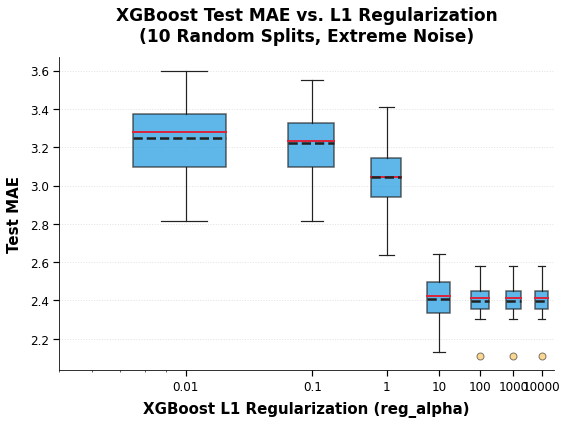

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

# 1. Generate data: sinusoidal signal + extreme noise
np.random.seed(42)
n_samples = 300

X = np.linspace(0, 10, n_samples).reshape(-1, 1)
y_true = np.sin(X).ravel()
noise = np.random.normal(0, 3.0, size=n_samples)  # Increase noise to make XGBoost fail
y = y_true + noise

# Regularization values to test (L1 regularization: reg_alpha)
reg_alphas = [0.01, 0.1, 1, 10, 100, 1000, 10000]
n_repeats = 10

# Store MAEs for each reg_alpha
xgb_maes_dict = {alpha: [] for alpha in reg_alphas}

for seed in range(n_repeats):
    # Split into train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed
    )
    for alpha in reg_alphas:
        xgb = XGBRegressor(
            reg_alpha=alpha,
            random_state=seed,
            verbosity=0,
            n_jobs=1
        )
        xgb.fit(X_train, y_train)
        y_pred_xgb = xgb.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred_xgb)
        xgb_maes_dict[alpha].append(mae)

# Prepare data for boxplot
mae_data = [xgb_maes_dict[alpha] for alpha in reg_alphas]

# Professional boxplot styling
plt.figure(figsize=(8, 6))
box = plt.boxplot(
    mae_data,
    patch_artist=True,
    showmeans=True,
    meanline=True,
    boxprops=dict(facecolor='#1B98E0', color='#222222', linewidth=1.5, alpha=0.7),
    medianprops=dict(color='#D7263D', linewidth=2),
    whiskerprops=dict(color='#222222', linewidth=1.2),
    capprops=dict(color='#222222', linewidth=1.2),
    meanprops=dict(color='#222222', linewidth=2.5),
    flierprops=dict(marker='o', markerfacecolor='#F7B32B', markersize=7, alpha=0.5)
)

plt.xscale('log')
plt.xticks(
    ticks=range(1, len(reg_alphas) + 1),
    labels=[str(a) for a in reg_alphas],
    fontsize=13
)
plt.xlabel("XGBoost L1 Regularization (reg_alpha)", fontsize=15, fontweight='bold', labelpad=8)
plt.ylabel("Test MAE", fontsize=15, fontweight='bold', labelpad=8)
plt.title(
    "XGBoost Test MAE vs. L1 Regularization\n(10 Random Splits, Extreme Noise)",
    fontsize=17, fontweight='bold', pad=16
)
plt.grid(True, linestyle=':', linewidth=1, alpha=0.35, axis='y')
plt.tick_params(axis='both', which='major', labelsize=12, length=6, width=1.2)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
